# CC3045 – Deep Learning · Laboratorio 9
## Modelos generativos: VAE y difusión sobre Fashion-MNIST

Todo el código está escrito con tensores de PyTorch. Las fórmulas del VAE (reparametrización, KL, pérdida),
del proceso forward de difusión y de los calendarios están implementadas a mano; no se usa `diffusers`,
`torch.distributions` ni calendarios prefabricados.

**Semilla aleatoria: `SEED = 42`** (se fija para `random`, `numpy` y `torch`, CPU y CUDA).

In [1]:
import os, json, math, time, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt
from torchvision import datasets

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device, torch.cuda.get_device_name(0) if device.type == "cuda" else "")
print("torch", torch.__version__)

os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)
RESULTS = {}  # aquí se guardan todos los números que se reportan en el documento

CLASSES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
           "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

device: cuda NVIDIA GeForce RTX 5060 Laptop GPU
torch 2.11.0+cu128


# Task 1

## Task 1.1 – Datos y configuración
Se escalan los píxeles a $[0,1]$ y los **últimos 5 000** ejemplos de entrenamiento se separan como validación.
Como el conjunto cabe en memoria, se carga completo en la GPU y los mini-lotes se toman por indexación.

In [2]:
train_raw = datasets.FashionMNIST("data", train=True, download=True)
test_raw  = datasets.FashionMNIST("data", train=False, download=True)

X_all = train_raw.data.float().div(255.).unsqueeze(1)    # (60000,1,28,28) en [0,1]
Y_all = train_raw.targets.clone()
X_train, Y_train = X_all[:-5000].to(device), Y_all[:-5000].to(device)   # 55 000
X_val,   Y_val   = X_all[-5000:].to(device), Y_all[-5000:].to(device)   # últimos 5 000
print(X_train.shape, X_val.shape, X_train.min().item(), X_train.max().item())

# configuración pedida
batch_size  = 128
latent_dim  = 2
epochs      = 20
lr          = 1e-3
beta_values = [0.1, 1.0, 10.0]

torch.Size([55000, 1, 28, 28]) torch.Size([5000, 1, 28, 28]) 0.0 1.0


## Task 1.2 – VAE
Arquitectura convolucional (idéntica para los tres $\beta$):

* **Encoder** $q_\phi(z\mid x)$: `Conv(1→32, 28→14)` → `Conv(32→64, 14→7)` → `Linear(3136→256)` → dos cabezas lineales
  que producen $\mu\in\mathbb{R}^2$ y $\log\sigma^2\in\mathbb{R}^2$.
* **Decoder** $p_\theta(x\mid z)$: `Linear(2→256→3136)` → `ConvT(64→32, 7→14)` → `ConvT(32→1, 14→28)` → sigmoide
  (la salida $\hat x$ es la media del decoder, en $[0,1]$).

Fórmulas escritas a mano (diapositivas de VAE):

* (a) Reparametrización: $z=\mu+\sigma\odot\epsilon,\ \epsilon\sim\mathcal N(0,I),\ \sigma=\exp(\tfrac12\log\sigma^2)$.
* (b) KL en forma cerrada: $D_{KL}\big(\mathcal N(\mu,\mathrm{diag}\,\sigma^2)\,\Vert\,\mathcal N(0,I)\big)=\tfrac12\sum_{j}\left(\mu_j^2+\sigma_j^2-\log\sigma_j^2-1\right)$.
* (c) Pérdida por imagen: $\mathcal L_\beta=\lVert x-\hat x\rVert^2+\beta\,D_{KL}$, con el error cuadrático **sumado** sobre los 784 píxeles
  (y promediado sobre las imágenes del lote).

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super().__init__()
        # Encoder q_phi(z|x): imagen -> (mu, log sigma^2)
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 4, 2, 1), nn.ReLU(),     # 28 -> 14
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),    # 14 -> 7
            nn.Flatten(), nn.Linear(64 * 7 * 7, 256), nn.ReLU())
        self.fc_mu     = nn.Linear(256, latent_dim)   # mu(x)
        self.fc_logvar = nn.Linear(256, latent_dim)   # log sigma^2(x)
        # Decoder p_theta(x|z): z -> x_hat (media del decoder)
        self.dec_fc = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(),
            nn.Linear(256, 64 * 7 * 7), nn.ReLU())
        self.dec = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),   # 7 -> 14
            nn.ConvTranspose2d(32, 1, 4, 2, 1), nn.Sigmoid()) # 14 -> 28, en [0,1]

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        return self.dec(self.dec_fc(z).view(-1, 64, 7, 7))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = reparametrize(mu, logvar)
        return self.decode(z), mu, logvar


def reparametrize(mu, logvar):
    # (a) z = mu + sigma ⊙ eps,  eps ~ N(0, I);  sigma = exp(0.5 log sigma^2)
    #     El ruido se separa de los parámetros, así el gradiente fluye a mu y sigma.
    eps = torch.randn_like(mu)
    return mu + torch.exp(0.5 * logvar) * eps


def kl_closed_form(mu, logvar):
    # (b) KL( N(mu, diag sigma^2) || N(0, I) ) = 1/2 * sum_j ( mu_j^2 + sigma_j^2 - log sigma_j^2 - 1 )
    #     sumada sobre las dimensiones latentes -> un valor por imagen (en nats)
    return 0.5 * torch.sum(mu.pow(2) + logvar.exp() - logvar - 1.0, dim=1)


def vae_loss(x, x_hat, mu, logvar, beta):
    # (c) L_beta = ||x - x_hat||^2 + beta * KL, error cuadrático sumado sobre los 784 píxeles
    recon = torch.sum((x - x_hat).pow(2), dim=(1, 2, 3))    # por imagen
    kl = kl_closed_form(mu, logvar)                          # por imagen
    return (recon + beta * kl).mean(), recon.mean(), kl.mean()

print("parámetros del VAE:", sum(p.numel() for p in VAE().parameters()))

parámetros del VAE: 1677509


In [4]:
@torch.no_grad()
def evaluate_vae(model, X, beta, bs=1000):
    # Métricas de validación por imagen: recon (SSE), KL (nats) y pérdida total
    model.eval(); r_sum = k_sum = 0.0
    for i in range(0, len(X), bs):
        x = X[i:i + bs]
        x_hat, mu, logvar = model(x)
        _, r, k = vae_loss(x, x_hat, mu, logvar, beta)
        r_sum += r.item() * len(x); k_sum += k.item() * len(x)
    return r_sum / len(X), k_sum / len(X)


def train_vae(beta):
    set_seed(SEED)                       # misma inicialización y mismo orden de lotes para cada beta
    model = VAE(latent_dim).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    hist = {"train_loss": [], "val_recon": [], "val_kl": []}
    n = len(X_train)
    for ep in range(epochs):
        model.train(); perm = torch.randperm(n, device=device); tot = 0.0
        for i in range(0, n, batch_size):
            x = X_train[perm[i:i + batch_size]]
            x_hat, mu, logvar = model(x)
            loss, _, _ = vae_loss(x, x_hat, mu, logvar, beta)
            opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(x)
        vr, vk = evaluate_vae(model, X_val, beta)
        hist["train_loss"].append(tot / n); hist["val_recon"].append(vr); hist["val_kl"].append(vk)
        print(f"beta={beta:<4} ep {ep+1:2d}  train L={tot/n:8.3f}  val recon={vr:7.3f}  val KL={vk:6.3f}")
    torch.save(model.state_dict(), f"checkpoints/vae_beta{beta}.pt")
    return model, hist

vaes, hists = {}, {}
t0 = time.time()
for beta in beta_values:
    vaes[beta], hists[beta] = train_vae(beta)
print(f"tiempo total de entrenamiento: {time.time()-t0:.1f}s")
RESULTS["vae_hist"] = {str(b): h for b, h in hists.items()}

beta=0.1  ep  1  train L=  34.583  val recon= 25.693  val KL= 7.883


beta=0.1  ep  2  train L=  25.335  val recon= 24.788  val KL= 7.663


beta=0.1  ep  3  train L=  24.229  val recon= 23.203  val KL= 7.782


beta=0.1  ep  4  train L=  23.536  val recon= 22.833  val KL= 7.681


beta=0.1  ep  5  train L=  23.071  val recon= 22.283  val KL= 7.891


...

beta=10.0 ep 16  train L=  53.236  val recon= 36.230  val KL= 1.717


beta=10.0 ep 17  train L=  53.239  val recon= 34.553  val KL= 1.895


beta=10.0 ep 18  train L=  53.321  val recon= 36.963  val KL= 1.669


beta=10.0 ep 19  train L=  53.134  val recon= 38.615  val KL= 1.545


beta=10.0 ep 20  train L=  53.196  val recon= 34.829  val KL= 1.858
tiempo total de entrenamiento: 184.4s


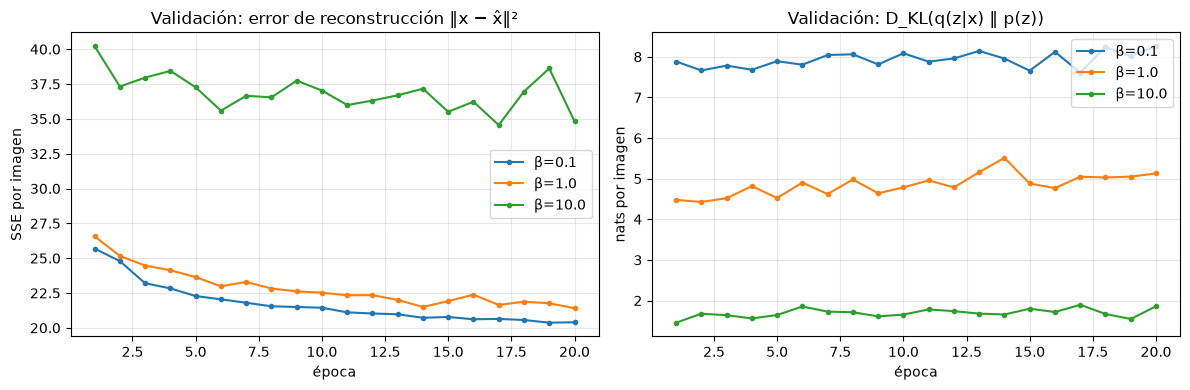

In [5]:
# Curvas de validación: error de reconstrucción y KL por época, para cada beta
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ep_axis = np.arange(1, epochs + 1)
for beta in beta_values:
    ax[0].plot(ep_axis, hists[beta]["val_recon"], marker="o", ms=3, label=f"β={beta}")
    ax[1].plot(ep_axis, hists[beta]["val_kl"], marker="o", ms=3, label=f"β={beta}")
ax[0].set(title="Validación: error de reconstrucción ‖x − x̂‖²", xlabel="época", ylabel="SSE por imagen")
ax[1].set(title="Validación: D_KL(q(z|x) ‖ p(z))", xlabel="época", ylabel="nats por imagen")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.savefig("figures/t1_2_curvas_validacion.png", dpi=150); plt.show()